# Week 8 — Zero Padding, Feedback, and IIR Filters

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

def time_axis(fs, duration):
    T = 1/fs
    t = np.arange(0, duration, T)
    return t

def generate_sine(f, t, A=1, p=0):
    y = A * np.sin(2 * np.pi * f * t + p)
    return y

## Resolution, the n argument, and zero padding

Text(0.5, 1.0, 'freq 5.0Hz')

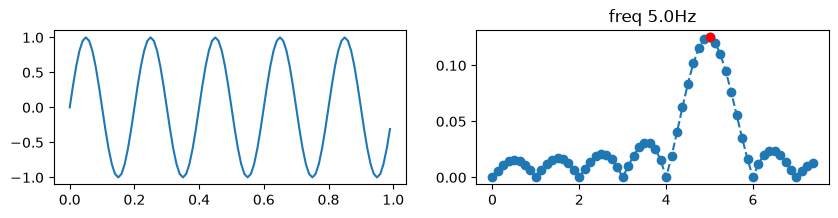

In [35]:
# Ex1: n-point fft on normal signal
# สร้างสัญญาณ sine ความถี่ on-bin แล้วแสดง spectrum
# ทดลองปรับค่า N-point FFT

def spectrum(x, NFFT=-1):
    if NFFT == -1:
        NFFT = len(x)
    X = np.fft.fft(x, NFFT)
    N = len(X)
    X = X[:N//2]
    mag = np.abs(X)*2/N
    freq = np.arange( len(mag) ) * fs / N
    return freq, mag

fs = 100
t = time_axis(fs, 1.0)
x = generate_sine(5, t)

plt.figure(figsize=(10,2))
plt.subplot(1, 2, 1)
plt.plot(t, x)

freq, mag = spectrum(x, NFFT = 8*len(x))
peak = np.argmax(mag)
plt.subplot(1, 2, 2)
plt.plot(freq[:60], mag[:60], '--o')
plt.plot(freq[peak], mag[peak], 'or')
plt.title(f"freq {freq[peak]}Hz")

mag: 0.5
freq: 5.0


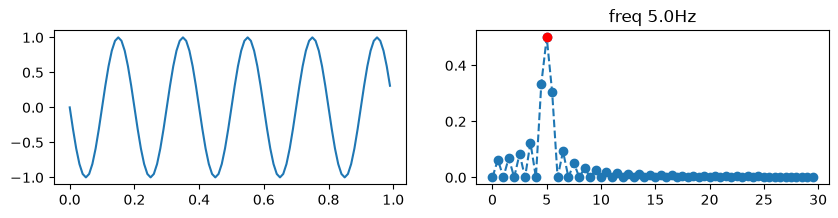

In [59]:
# Ex1: n-point fft on offbin signal
# สร้างสัญญาณ sine ความถี่ off-bin แล้วแสดง spectrum
# ทดลองปรับค่า N-point FFT

fs = 100
t = time_axis(fs, 1.0)
x = generate_sine(5, t, 1, np.pi)

plt.figure(figsize=(10,2))
plt.subplot(1, 2, 1)
plt.plot(t, x)

freq, mag = spectrum(x, NFFT = int(2*len(x)))
peak_index = np.argmax(mag)
plt.subplot(1, 2, 2)
plt.plot(freq[:60], mag[:60], '--o')
plt.plot(freq[peak_index], mag[peak_index], 'or')
plt.title(f"freq {freq[peak_index]}Hz")
print("mag:", mag[peak_index])
print("freq:", freq[peak_index])

m## Apply FIR filter

20


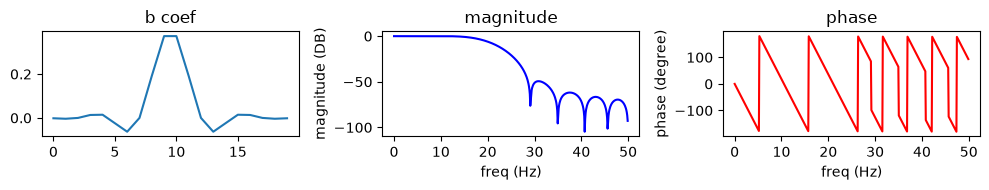

In [76]:
# Create FIR filter
# สร้างตัวกรอง FIR 
fs = 100
b = signal.firwin(numtaps=20, cutoff=20, fs=fs)
a = [1.0]

# b คือ สัมประสิทธิ์ของตัวกรอง และสำหรับระบบ feedforward มันคือ h[n] ของระบบเลย
print(len(b))
plt.figure(figsize=(10, 2))
plt.subplot(1, 3, 1)
plt.plot(b)
plt.title("b coef")
# นำ b กับ a ไปคำนวณการตอบสนองทางความถี่ ด้วย freqz
# omega = w frequency, h = complex frequency
w, h = signal.freqz(b, a, fs = fs)
# mag = np.abs(h)
mag = 20 * np.log10(np.abs(h)) # change to db
plt.subplot(1, 3, 2)
plt.plot(w, mag, 'b')
plt.xlabel("freq (Hz)"); plt.ylabel("magnitude (DB)"); plt.title("magnitude")

phase = np.angle(h, deg = True)
plt.subplot(1, 3, 3)
plt.plot(w, phase, 'r')
plt.xlabel("freq (Hz)"); plt.ylabel("phase (degree)"); plt.title("phase")

plt.tight_layout()

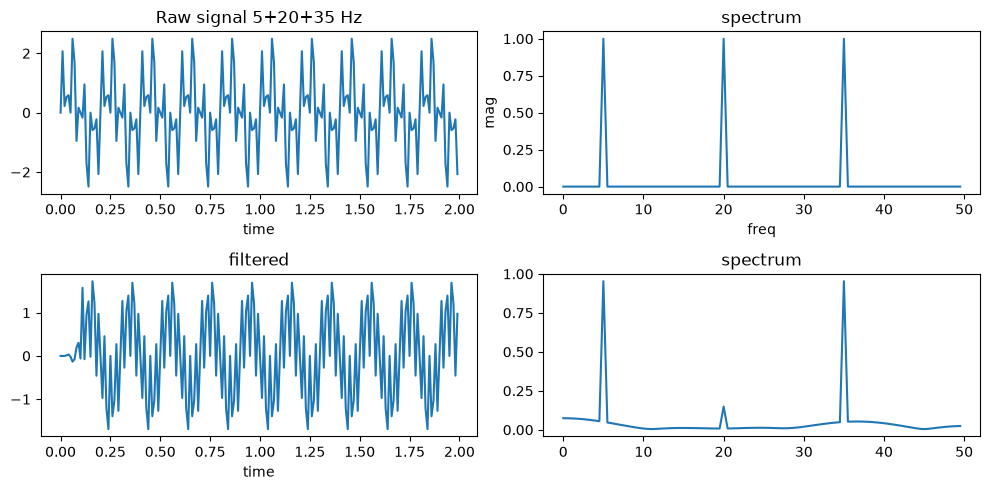

In [91]:
# Apply FIR filter
# สร้างสัญญาณ
fs = 100
t = time_axis(fs, 2.0)
x = generate_sine(5, t) + generate_sine(20, t) + generate_sine(35, t)
plt.figure(figsize = (10, 5))
plt.subplot(2, 2, 1)
plt.plot(t, x)
plt.xlabel("time");plt.title("Raw signal 5+20+35 Hz")

freq, mag = spectrum(x)
plt.subplot(2,2,2)
plt.plot(freq, mag)
plt.xlabel("freq"); plt.ylabel("mag"); plt.title("spectrum")
# สร้างตัวกรอง FIR 
fs = 100
b = signal.firwin(numtaps=21, cutoff=[15, 25], fs=fs, pass_zero = "bandstop")
a = [1.0]

# ใช้ตัวกรอง
y = signal.lfilter(b, a, x)
plt.subplot(2, 2, 3)
plt.plot(t, y)
plt.xlabel("time"); plt.title("filtered")

freq, mag = spectrum(y)
plt.subplot(2, 2, 4)
plt.plot(freq, mag)
plt.title("spectrum")
plt.tight_layout()

Text(0.5, 1.0, 'spectrum')

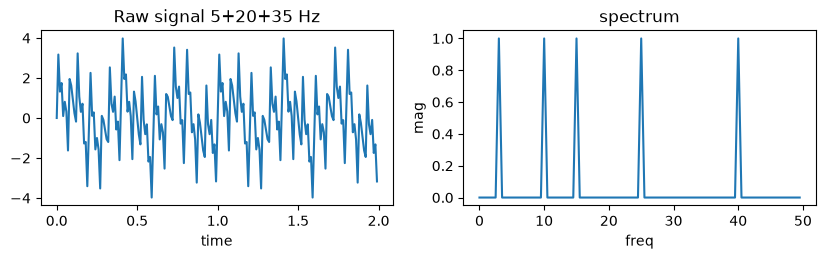

In [92]:
# Ex2: filter a multi frequency signal
# สร้างสัญญาณ sine ความถี่ 3, 10, 15, 25, 40 Hz ที่ fs=100, duration=2
fs = 100
duration = 2
t = time_axis(fs, duration)
x = generate_sine(3, t) + generate_sine(10, t) + generate_sine(15, t) + generate_sine(25, t) + generate_sine(40, t)


plt.figure(figsize = (10, 5))
plt.subplot(2, 2, 1)
plt.plot(t, x)
plt.xlabel("time");plt.title("Raw signal 5+20+35 Hz")

freq, mag = spectrum(x)
plt.subplot(2,2,2)
plt.plot(freq, mag)
plt.xlabel("freq"); plt.ylabel("mag"); plt.title("spectrum")


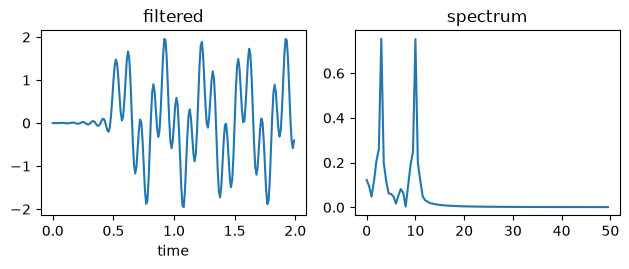

In [122]:
# ออกแบบตัวกรองให้ กรองสัญญาณเหลือ 3, และ 10 Hz
b = signal.firwin(numtaps=101, cutoff=12, fs=fs, pass_zero = "lowpass")
a = [1.0]
# ใช้ตัวกรอง
y = signal.lfilter(b, a, x)
plt.subplot(2, 2, 3)
plt.plot(t, y)
plt.xlabel("time"); plt.title("filtered")

freq, mag = spectrum(y)
plt.subplot(2, 2, 4)
plt.plot(freq, mag)
plt.title("spectrum")
plt.tight_layout()

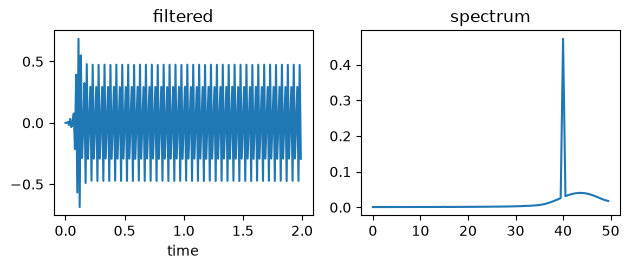

In [118]:
# ออกแบบตัวกรองให้ กรองสัญญาณเหลือ 40 Hz
b = signal.firwin(numtaps=21, cutoff=40, fs=fs, pass_zero = "highpass")
a = [1.0]
# ใช้ตัวกรอง
y = signal.lfilter(b, a, x)
plt.subplot(2, 2, 3)
plt.plot(t, y)
plt.xlabel("time"); plt.title("filtered")

freq, mag = spectrum(y)
plt.subplot(2, 2, 4)
plt.plot(freq, mag)
plt.title("spectrum")
plt.tight_layout()

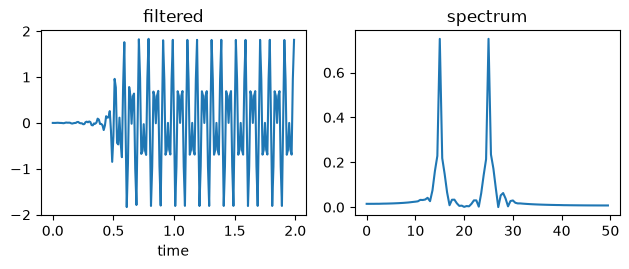

In [127]:
# ออกแบบตัวกรองให้ กรองสัญญาณเหลือ 15, และ 25 Hz
b = signal.firwin(numtaps=101, cutoff=[12, 30], fs=fs, pass_zero = "bandpass")
a = [1.0]
# ใช้ตัวกรอง
y = signal.lfilter(b, a, x)
plt.subplot(2, 2, 3)
plt.plot(t, y)
plt.xlabel("time"); plt.title("filtered")

freq, mag = spectrum(y)
plt.subplot(2, 2, 4)
plt.plot(freq, mag)
plt.title("spectrum")
plt.tight_layout()

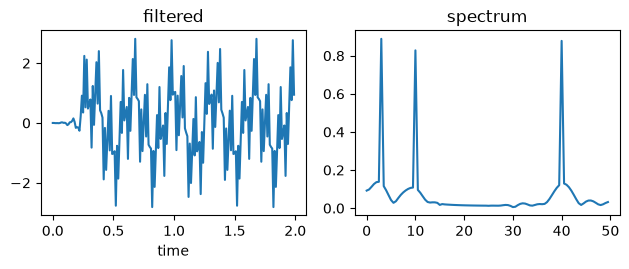

In [153]:
# ออกแบบตัวกรองให้ กรองสัญญาณลบ 15, และ 25 Hz
b = signal.firwin(numtaps=51, cutoff=[12, 30], fs=fs, pass_zero = "bandstop")
a = [1.0]
# ใช้ตัวกรอง
y = signal.lfilter(b, a, x)
plt.subplot(2, 2, 3)
plt.plot(t, y)
plt.xlabel("time"); plt.title("filtered")

freq, mag = spectrum(y)
plt.subplot(2, 2, 4)
plt.plot(freq, mag)
plt.title("spectrum")
plt.tight_layout()

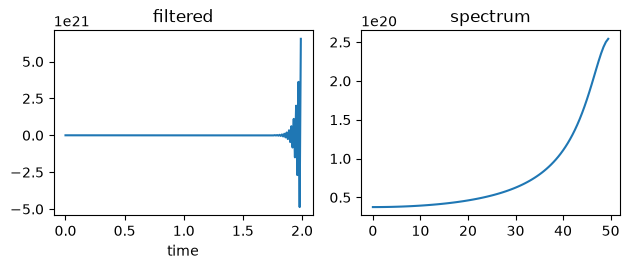

In [154]:
# ออกแบบตัวกรองให้ กรองสัญญาณลบ 15, และ 25 Hz
b = signal.firwin(numtaps=51, cutoff=[12, 30], fs=fs, pass_zero = "bandstop")
a = [1, 1, 1, 1, -1,1 , 1, 1, 1]
# ใช้ตัวกรอง
y = signal.lfilter(b, a, x)
plt.subplot(2, 2, 3)
plt.plot(t, y)
plt.xlabel("time"); plt.title("filtered")

freq, mag = spectrum(y)
plt.subplot(2, 2, 4)
plt.plot(freq, mag)
plt.title("spectrum")
plt.tight_layout()